# **Downloading the Data**

Using the Requets  -- downloading the data through link --> https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

In [ ]:
#Downlaoding the Data
import requests

URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

request = requests.get(URL)
with open("data.tar", "wb") as f:
  f.write(request.content)
print("Done")

Done


### **Reading the Tar file**

reading the tar file and extracting all the file

In [ ]:
import tarfile as t

with t.open('data.tar', 'r:gz') as f:
  f.extractall()

print('data.tar Is extracted , DONE :)')

FileNotFoundError: [Errno 2] No such file or directory: 'data.tar'

In [ ]:
# 1. preparing the Data
!pip install pyprind
import pyprind
import pandas as pd
import os
import sys

print("Instalation and importing is DONE")

Instalation and importing is DONE


In [ ]:
from tqdm.auto import tqdm   ## this is the progress bar
BASEPATH = '/content/aclImdb'
labels = {'pos': 1,
          'neg': 0}

df = pd.DataFrame(columns=['review','sentiments'])
for s in ('test' , 'train'):
  for l in('pos','neg'):
    path = os.path.join(BASEPATH , s ,l)
    for file in tqdm(sorted(os.listdir(path))):
      with open(os.path.join(path, file),'r' , encoding='utf-8') as infile:
        txt = infile.read()
      df.loc[len(df)] = [txt, labels[l]]




  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

In [ ]:
# 2. simce the Data is we saperated need to reshuffle
import numpy as np
np.random.seed(0)
df = df.reindex(np.random.permutation(df.index))

df.to_csv("movie_data.csv" , index=False , encoding = 'utf-8')

# **Transforming the words into feature Vectors**

Using the `sklearn.feature_extraction.text` and `CountVectorizer`

`CountVectorizer`  --> To construct a bag-of-words based on the words count in the respective documents

What is a **Bag-of-Words**

1. we create a vocabulary of the unique tokens - eg words from the entire dataset
2. We construct a feature vector that contain the count how often the words occur in particular documents

In [ ]:
# Tranforming words into feature vectors
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
counts = CountVectorizer()

# Eg. of how it is going to work
docs = np.array(['The Moon is white',
                 'The Waether is sweet',
                 'The moon is white , The weather is sweet',
                 'And one and one is two'])
BAG = counts.fit(docs)

In [ ]:
BAG = counts.transform(docs)

In [ ]:
# Looking at What model Just model did
print('The counts of the vocab is in form of dictionary \n',counts.vocabulary_)

The counts of the vocab is in form of dictionary 
 {'the': 5, 'moon': 2, 'is': 1, 'white': 9, 'waether': 7, 'sweet': 4, 'weather': 8, 'and': 0, 'one': 3, 'two': 6}


In [ ]:
print('The feature vectors for this dictinary \n', BAG.toarray())

The feature vectors for this dictinary 
 [[0 1 1 0 0 1 0 0 0 1]
 [0 1 0 0 1 1 0 1 0 0]
 [0 2 1 0 1 2 0 0 1 1]
 [2 1 0 2 0 0 1 0 0 0]]


### **Assesing Word relevency via TFIDF**

with the `l2 normalization`
`l2` --> L2 regularization, is a technique used in linear regression to prevent overfitting by adding a penalty term to the loss function. This penalty is proportional to the square of the magnitude of the coefficients

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

# setting the tfidf tranformer
tfidf = TfidfTransformer(use_idf= True,
                         smooth_idf= True,
                         norm = 'l2')
np.set_printoptions(precision=2)  ### This actually set out the output of the numpy array [0.34556] --> [0.34]

print(tfidf.fit_transform(counts.fit_transform(docs)).toarray())

[[0.   0.38 0.57 0.   0.   0.46 0.   0.   0.   0.57]
 [0.   0.34 0.   0.   0.52 0.42 0.   0.66 0.   0.  ]
 [0.   0.44 0.33 0.   0.33 0.54 0.   0.   0.42 0.33]
 [0.66 0.17 0.   0.66 0.   0.   0.33 0.   0.   0.  ]]


### **Cleaning Of the Data**

The previous is the example of the tfidf works now we need it to apply on the model so first we need to remove the unwanted words and start the cleaning process

In [ ]:
df.head()

,review,sentiments
11841,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
19602,OK... so... I really like Kris Kristofferson a...,0
45519,"***SPOILER*** Do not read this, if you think a...",0
25747,hi for all the people who have seen this wonde...,1
42642,"I recently bought the DVD, forgetting just how...",0


In [ ]:
### Checking the random Review

idx = df.sample(1).index[0] # this is for the random ness
print(df.loc[idx,'review'][-100:])
print("The Index of the review is  ",idx)

# 2. The example should look like this
# ften underestimated and forgotten, but very worthy.<br /><br />This should definitely be on Top 250.
# The Index of the review is   (5680)

ablished at the time or just starting out. A very good film well worth watching. Highly recommended.
The Index of the review is   35356


In [ ]:
# Setting the cleaning Function
import re

def text_preprocessor(text):
    text = re.sub(r'<[^>]*>', '', text)

    emoticons = re.findall(
        r'(?::|;|=)(?:-)?(?:\)|\(|D|P)',
        text
    )

    text = (
        re.sub(r'[\W]+', ' ', text.lower())
        + ' '.join(emoticons).replace('-', '')
    )

    return text

# checking for the 1 sample

text = df.loc[5680, 'review'][-100:]

# Testing the pre processor
test = text_preprocessor(text=text)
test

'ften underestimated and forgotten but very worthy this should definitely be on top 250 '

In [ ]:
# Applying to whole dataset

df['review'] = df['review'].apply(text_preprocessor)

## **Processing Documents into Tokens**

after succesfully cleaning the data from the abnormalities now we need to think how can saperate the text into split individual elemenst

#### *Using the porter.stem method*
`from nltk.stem.porter import PorterStemmer` <-- it is basically an advance version of our function where it can return the text in the base form

this is the oldest stemming algo but there are newre also
* snowBall stemmer
* Lancaster stemmer

*what does the stemming do is*

a text preprocessing technique that reduces words to their canonical dictionary base form (known as a "lemma") based on their intended meaning and part of speech

In [ ]:
# 1. Creating the tokenizer function

def tokenizer(text):
  """This function is used to split the text and help tkenize them """
  return text.split()

# 2. Testing the function
tokenizer('This is the testing function and testing is on the data')

['This',
 'is',
 'the',
 'testing',
 'function',
 'and',
 'testing',
 'is',
 'on',
 'the',
 'data']

In [ ]:
#1. using the porterstem method
from nltk.stem.porter import PorterStemmer
porter = PorterStemmer()

# 2. creating the function using the Porterstemmer
def stem_tokenizer(text):
  """Using the stemmer NLTK"""
  return [porter.stem(word) for word in text.split()]

# 3. testiing the function
stem_tokenizer('this is the testing function and testing is on the data')

['thi',
 'is',
 'the',
 'test',
 'function',
 'and',
 'test',
 'is',
 'on',
 'the',
 'data']

## **STOP WORDS REMOVAL**

In [ ]:
import nltk

nltk.download('stopwords')
print("DOWNLAOD , DONE")

DOWNLAOD , DONE


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from nltk.corpus import stopwords
stop = stopwords.words('english') # < choosinf the english
[w for w in stem_tokenizer('this is the testing function and testing is on the data') if w not in stop]

['thi', 'test', 'function', 'test', 'data']

# **Training the Logistic regression Model For this document classification**

splitting the data In train and test , With Hyper parameters tuning and choosing the best parameteers

1. creating the Dictionary for parameters `small_params_grid`
2. creating the pipeline for `TFIDF` and `LogisticRegression`
3. Creating the model and passing the values in `GridSearchCV`

In [ ]:
# 1. splitting the data
### dividing the data equally in 25k for trainng and testing
X_train = df.loc[:25000, 'review'].values
y_train = df.loc[:25000, 'sentiments'].values
X_test = df.loc[25000:, 'review'].values
y_test = df.loc[25000:, 'sentiments'].values

len(X_train), len(X_test), len(y_train), len(y_test)

(20448, 29553, 20448, 29553)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. creating the Tfidf Vectorizer to convert the values into dictionaries
tfidf = TfidfVectorizer(strip_accents= None,
                        lowercase = False,
                        preprocessor = None)

# 2. creating the small_param_grid

small_param_grid = [
    {
        'vect__ngram_range':[(1,1)],
        'vect__stop_words': [None],
        'vect__tokenizer' : [tokenizer , stem_tokenizer],
        'clf__penalty': ['l2'],
        'clf__C' : [1.0 , 10.0]
    },
    {
        'vect__ngram_range':[(1,1)],
        'vect__stop_words': [stop, None],
        'vect__tokenizer' : [tokenizer],
        'vect__use_idf' : [False],
        'vect__norm' : [None],
        'clf__penalty': ['l2'],
        'clf__C' : [1.0 , 10.0]
    }
]

# 3. Creating the pipeline
lr_tfidf = Pipeline([
    ('vect' , tfidf),
    ('clf', LogisticRegression(solver= 'liblinear'))
    ])

# 4. creating instance for the Model
gs_lr_tfidf = GridSearchCV(lr_tfidf , small_param_grid , scoring = 'accuracy' , cv = 5 , verbose = 2, n_jobs=1)

# 5. FITTING THE MODEL
gs_lr_tfidf.fit(X_train , y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[CV] END clf__C=1.0, clf__penalty=l2, vect__ngram_range=(1, 1), vect__stop_words=None, vect__tokenizer=<function tokenizer at 0x7e2fab83b7e0>; total time=   3.2s


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[CV] END clf__C=1.0, clf__penalty=l2, vect__ngram_range=(1, 1), vect__stop_words=None, vect__tokenizer=<function tokenizer at 0x7e2fab83b7e0>; total time=   3.3s


...

[CV] END clf__C=10.0, clf__penalty=l2, vect__ngram_range=(1, 1), vect__norm=None, vect__stop_words=None, vect__tokenizer=<function tokenizer at 0x7e2fab83b7e0>, vect__use_idf=False; total time=  13.1s


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[CV] END clf__C=10.0, clf__penalty=l2, vect__ngram_range=(1, 1), vect__norm=None, vect__stop_words=None, vect__tokenizer=<function tokenizer at 0x7e2fab83b7e0>, vect__use_idf=False; total time=  13.9s


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vect',
                                        TfidfVectorizer(lowercase=False)),
                                       ('clf',
                                        LogisticRegression(solver='liblinear'))]),
             n_jobs=1,
             param_grid=[{'clf__C': [1.0, 10.0], 'clf__penalty': ['l2'],
                          'vect__ngram_range': [(1, 1)],
                          'vect__stop_words': [None],
                          'vect__tokenizer': [<function tokenizer at 0x7e2fab83b7e0>,
                                              <function stem_tokenizer at 0x7e2fab83b880>]}...
                          'vect__stop_words': [['a', 'about', 'above', 'after',
                                                'again', 'against', 'ain',
                                                'all', 'am', 'an', 'and', 'any',
                                                'are', 'aren', "aren't", 'as',
                                                'at', 'be', 'because', 'been',
                                                'before', 'being', 'below',
                                                'between', 'both', 'but', 'by',
                                                'can', 'couldn', "couldn't", ...],
                                               None],
                          'vect__tokenizer': [<function tokenizer at 0x7e2fab83b7e0>],
                          'vect__use_idf': [False]}],
             scoring='accuracy', verbose=2)

In [ ]:
print(f"The best Parameter are {gs_lr_tfidf.best_params_}")
print(f"The best scores are {gs_lr_tfidf.best_score_}")

The best Parameter are {'clf__C': 10.0, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 1), 'vect__stop_words': None, 'vect__tokenizer': <function tokenizer at 0x7e2fab83b7e0>}
The best scores are 0.891481038339489


In [ ]:
clf = gs_lr_tfidf.best_estimator_
print(f"The Accuracy is {clf.score(X_test , y_test)}")

The Accuracy is 0.8972016377355937


## **SAVING THE PKL**

To save this model we need to import the pkl file

In [ ]:
import pickle


# 1. saving the model

with open('Sentiment_model.pkl' , 'wb') as f:
  pickle.dump(clf , f)


### Implementing the **KERAS NN** on this

In [ ]:
from tensorflow import keras

print(keras.__version__)
print("Print is Done")

3.13.2
Print is Done


In [ ]:
# splitting the Data Again
from sklearn.model_selection import train_test_split
X = df['review']
y = df['sentiments']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 ,stratify = y, random_state = 42)

len(X_train), len(X_test), len(y_train), len(y_test)

# spliting the Data into validation set
X_train , X_val , y_train , y_val = train_test_split(X_train , y_train , test_size = 0.2 ,stratify = y_train, random_state = 42)



In [ ]:
len(X_train), len(X_val), len(y_train), len(y_val)

(32000, 8000, 32000, 8000)

In [ ]:
# 1. Checking the X_train and Xtest data
print(f"This is X_train : {X_train[0]}")

# 2. Coverting this raw text to the Vector to feed in the  Nn

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_nn = TfidfVectorizer(stop_words = stop,
                           ngram_range= (1,1),
                           max_features = 5000,
                           tokenizer = stem_tokenizer)

print("Done")

This is X_train : i went and saw this movie last night after being coaxed to by a few friends of mine i ll admit that i was reluctant to see it because from what i knew of ashton kutcher he was only able to do comedy i was wrong kutcher played the character of jake fischer very well and kevin costner played ben randall with such professionalism the sign of a good movie is that it can toy with our emotions this one did exactly that the entire theater which was sold out was overcome by laughter during the first half of the movie and were moved to tears during the second half while exiting the theater i not only saw many women in tears but many full grown men as well trying desperately not to let anyone see them crying this movie was great and i suggest that you go see it before you judge 
Done


In [ ]:
# 3. passing the Data
import time
from tqdm import tqdm
pbar = tqdm(total=100)
X_TRAIN = tfidf_nn.fit_transform(X_train)
time.sleep(1)
pbar.update(33)
X_VAL = tfidf_nn.transform(X_val)
time.sleep(1)
pbar.update(66)
X_TEST = tfidf_nn.transform(X_test)
time.sleep(1)
pbar.update(100)
pbar.close()

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'doe', 'dure', 'ha', "he'", 'hi', "i'v", "it'", 'onc', 'onli', 'ourselv', "she'", "should'v", 'themselv', "they'r", "they'v", 'thi', 'veri', 'wa', "we'r", "we'v", 'whi', "you'r", "you'v", 'yourselv'] not in stop_words.
  warnings.warn(
199it [03:21,  1.01s/it]


In [ ]:
print(X_TRAIN.shape)
print(X_VAL.shape)
print(X_TEST.shape)

(32000, 5000)
(8000, 5000)
(10000, 5000)


In [ ]:
# coverting the sparse tfidf to dense array
X_train_dense = X_TRAIN.toarray()
X_test_dense = X_TEST.toarray()
X_val_dense = X_VAL.toarray()

print(type(X_TRAIN))
print(type(X_train_dense))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'numpy.ndarray'>


## **Creating the Keras NN**

from importing the Sequential creating the NN

In [ ]:
from keras import Sequential
from keras.layers import Dense , Dropout


# 1. Buildind the NN
model = Sequential([
    Dense(128 , activation = 'relu' , input_shape=(5000,)),
    Dropout(0.5),
    Dense(64 , activation = 'relu'),
    Dropout(0.5),
    Dense(1 , activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model are so accessible we can get the weight and bias of the models
hidden1 = model.layers[0]
weight , bias  = hidden1.get_weights()

In [ ]:
weight, bias # theses are the weight and bias of the model

(array([[-0.03,  0.02,  0.02, ...,  0.01, -0.02,  0.  ],
        [ 0.02,  0.01,  0.01, ..., -0.02,  0.  , -0.03],
        [-0.02, -0.02,  0.02, ..., -0.03, -0.  , -0.01],
        ...,
        [ 0.03,  0.01, -0.02, ...,  0.  ,  0.03, -0.02],
        [ 0.02,  0.03, -0.  , ...,  0.01,  0.03,  0.03],
        [-0.02, -0.  ,  0.01, ...,  0.01,  0.02,  0.03]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32))

In [ ]:
### Compilong the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training the  model

history = model.fit(X_train_dense,
                    y_train,
                    validation_data = (X_val_dense , y_val),
                    epochs = 5,
                    batch_size = 32
                    )

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.8504 - loss: 0.3440 - val_accuracy: 0.8917 - val_loss: 0.2657
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9113 - loss: 0.2312 - val_accuracy: 0.8884 - val_loss: 0.2728
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9333 - loss: 0.1784 - val_accuracy: 0.8860 - val_loss: 0.2996
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9550 - loss: 0.1310 - val_accuracy: 0.8839 - val_loss: 0.3313
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9704 - loss: 0.0899 - val_accuracy: 0.8821 - val_loss: 0.3827


In [ ]:
# Evaluating the mmodel
loss , acc = model.evaluate(X_test_dense , y_test)

print(f"Test Loss is {loss}")
print(f"Test Accuracy is {acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8796 - loss: 0.3782
Test Loss is 0.37823712825775146
Test Accuracy is 0.8795999884605408


In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

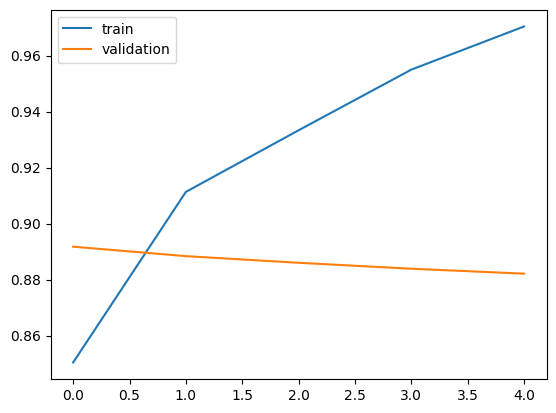

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

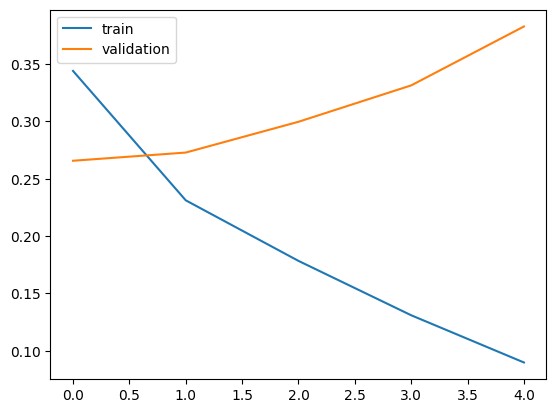

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()